# Football Analysis Modular Pipeline: Step-by-Step Processor Testing

This notebook demonstrates the modular football video analysis pipeline, testing each processor step by step with real video data and visualizing the results after each stage.

In [1]:
# Import core libraries for data handling and visualization
import cv2
import matplotlib.pyplot as plt
from football_ai.domain.data_models import VideoData, FrameData

import os


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/ray/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Load Real Data

We will load a sample football video, extract a few frames, and prepare the data for processing through the pipeline.

In [2]:
# Path to a sample video (update if needed)
video_path = 'input_videos/08fd33_4.mp4'
assert os.path.exists(video_path), f"Video not found: {video_path}"

cap = cv2.VideoCapture(video_path)
frame_rate = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration = cap.get(cv2.CAP_PROP_FRAME_COUNT) / frame_rate

frames = []
i = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(FrameData(
        frame_number=i,
        timestamp=cap.get(cv2.CAP_PROP_POS_MSEC) / 1000.0,
        raw_frame=frame
    ))
    i += 1
cap.release()

video_data = VideoData(
    video_path=video_path,
    frame_rate=frame_rate,
    resolution=(width, height),
    duration=duration,
    frames=frames
)

print(f"Loaded {len(frames)} frames from {video_path}")
model_paths = {
    'detection': 'models/detect/best.pt',
}

Loaded 750 frames from input_videos/08fd33_4.mp4


## Visualize Results After Each Processor

After each processor, we will visualize the results for the first frame to observe the changes and outputs at each stage.

In [3]:
# Object Detection
from football_ai.detection.object_detection_processor import ObjectDetectionProcessor
object_detection = ObjectDetectionProcessor(model_paths['detection'])
video_data = object_detection.process(video_data)

# Print the first data in the first frame after detection
print("First frame after object detection:")
print(video_data.frames[0])


First frame after object detection:
FrameData(frame_number=0, timestamp=0.0, raw_frame=array([[[100, 146, 105],
        [ 92, 138,  97],
        [ 97, 150, 101],
        ...,
        [100,  92,  82],
        [103,  95,  85],
        [105,  97,  87]],

       [[ 99, 145, 104],
        [ 99, 145, 104],
        [109, 162, 113],
        ...,
        [105,  97,  87],
        [107,  99,  89],
        [108, 100,  90]],

       [[ 96, 149, 100],
        [105, 158, 109],
        [112, 170, 113],
        ...,
        [106,  98,  88],
        [108, 100,  90],
        [110, 102,  92]],

       ...,

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
        ...,
        [ 30,  47,  43],
        [ 31,  48,  44],
        [ 31,  48,  44]],

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
        ...,
        [ 44,  56,  55],
        [ 46,  58,  57],
        [ 46,  58,  57]],

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],


In [4]:
# tracking
from football_ai.tracking.track_processor import TrackProcessor
tracker = TrackProcessor()
video_data = tracker.process(video_data)

# Print the first data in the first frame after tracking
print("First frame after tracking:")
print(video_data.frames[0])

First frame after tracking:
FrameData(frame_number=0, timestamp=0.0, raw_frame=array([[[100, 146, 105],
        [ 92, 138,  97],
        [ 97, 150, 101],
        ...,
        [100,  92,  82],
        [103,  95,  85],
        [105,  97,  87]],

       [[ 99, 145, 104],
        [ 99, 145, 104],
        [109, 162, 113],
        ...,
        [105,  97,  87],
        [107,  99,  89],
        [108, 100,  90]],

       [[ 96, 149, 100],
        [105, 158, 109],
        [112, 170, 113],
        ...,
        [106,  98,  88],
        [108, 100,  90],
        [110, 102,  92]],

       ...,

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
        ...,
        [ 30,  47,  43],
        [ 31,  48,  44],
        [ 31,  48,  44]],

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
        ...,
        [ 44,  56,  55],
        [ 46,  58,  57],
        [ 46,  58,  57]],

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
        

In [5]:
# Object motion 
from football_ai.motion.object_motion_processor import ObjectMotionProcessor
object_motion_processor = ObjectMotionProcessor()
video_data = object_motion_processor.process(video_data)

# Print the first data in the first frame after object motion
print("First frame after object motion:")
print(video_data.frames[0])

First frame after object motion:
FrameData(frame_number=0, timestamp=0.0, raw_frame=array([[[100, 146, 105],
        [ 92, 138,  97],
        [ 97, 150, 101],
        ...,
        [100,  92,  82],
        [103,  95,  85],
        [105,  97,  87]],

       [[ 99, 145, 104],
        [ 99, 145, 104],
        [109, 162, 113],
        ...,
        [105,  97,  87],
        [107,  99,  89],
        [108, 100,  90]],

       [[ 96, 149, 100],
        [105, 158, 109],
        [112, 170, 113],
        ...,
        [106,  98,  88],
        [108, 100,  90],
        [110, 102,  92]],

       ...,

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
        ...,
        [ 30,  47,  43],
        [ 31,  48,  44],
        [ 31,  48,  44]],

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
        ...,
        [ 44,  56,  55],
        [ 46,  58,  57],
        [ 46,  58,  57]],

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
   

In [6]:
# Camera motion
from football_ai.motion.camera_motion_processor import CameraMotionProcessor
camera_motion_processor = CameraMotionProcessor()
video_data = camera_motion_processor.process(video_data)

# Print the first data in the first frame after camera motion
print("First frame after camera motion:")
print(video_data.frames[0])

First frame after camera motion:
FrameData(frame_number=0, timestamp=0.0, raw_frame=array([[[100, 146, 105],
        [ 92, 138,  97],
        [ 97, 150, 101],
        ...,
        [100,  92,  82],
        [103,  95,  85],
        [105,  97,  87]],

       [[ 99, 145, 104],
        [ 99, 145, 104],
        [109, 162, 113],
        ...,
        [105,  97,  87],
        [107,  99,  89],
        [108, 100,  90]],

       [[ 96, 149, 100],
        [105, 158, 109],
        [112, 170, 113],
        ...,
        [106,  98,  88],
        [108, 100,  90],
        [110, 102,  92]],

       ...,

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
        ...,
        [ 30,  47,  43],
        [ 31,  48,  44],
        [ 31,  48,  44]],

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
        ...,
        [ 44,  56,  55],
        [ 46,  58,  57],
        [ 46,  58,  57]],

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
   

In [7]:
# field_transform
from football_ai.transformation.field_transformation_processor import FieldTransformationProcessor
field_transform = FieldTransformationProcessor()
video_data = field_transform.process(video_data)

# Print the first data in the first frame after field transformation
print("First frame after field transformation:")
print(video_data.frames[0])

First frame after field transformation:
FrameData(frame_number=0, timestamp=0.0, raw_frame=array([[[100, 146, 105],
        [ 92, 138,  97],
        [ 97, 150, 101],
        ...,
        [100,  92,  82],
        [103,  95,  85],
        [105,  97,  87]],

       [[ 99, 145, 104],
        [ 99, 145, 104],
        [109, 162, 113],
        ...,
        [105,  97,  87],
        [107,  99,  89],
        [108, 100,  90]],

       [[ 96, 149, 100],
        [105, 158, 109],
        [112, 170, 113],
        ...,
        [106,  98,  88],
        [108, 100,  90],
        [110, 102,  92]],

       ...,

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
        ...,
        [ 30,  47,  43],
        [ 31,  48,  44],
        [ 31,  48,  44]],

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
        ...,
        [ 44,  56,  55],
        [ 46,  58,  57],
        [ 46,  58,  57]],

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  7

In [8]:
# team assignment
from football_ai.assignment.team_assignment_processor import TeamAssignmentProcessor
team_assignment_processor = TeamAssignmentProcessor()
video_data = team_assignment_processor.process(video_data)
# Print the first data in the first frame after team assignment
print("First frame after team assignment:")
print(video_data.frames[0])

First frame after team assignment:
FrameData(frame_number=0, timestamp=0.0, raw_frame=array([[[100, 146, 105],
        [ 92, 138,  97],
        [ 97, 150, 101],
        ...,
        [100,  92,  82],
        [103,  95,  85],
        [105,  97,  87]],

       [[ 99, 145, 104],
        [ 99, 145, 104],
        [109, 162, 113],
        ...,
        [105,  97,  87],
        [107,  99,  89],
        [108, 100,  90]],

       [[ 96, 149, 100],
        [105, 158, 109],
        [112, 170, 113],
        ...,
        [106,  98,  88],
        [108, 100,  90],
        [110, 102,  92]],

       ...,

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
        ...,
        [ 30,  47,  43],
        [ 31,  48,  44],
        [ 31,  48,  44]],

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
        ...,
        [ 44,  56,  55],
        [ 46,  58,  57],
        [ 46,  58,  57]],

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
 

In [9]:
# ball assignment
from football_ai.assignment.ball_assignment_processor import BallAssignmentProcessor
ball_assignment_processor = BallAssignmentProcessor()
video_data = ball_assignment_processor.process(video_data)
# Print the first data in the first frame after ball assignment
print("First frame after ball assignment:")
print(video_data.frames[0])

First frame after ball assignment:
FrameData(frame_number=0, timestamp=0.0, raw_frame=array([[[100, 146, 105],
        [ 92, 138,  97],
        [ 97, 150, 101],
        ...,
        [100,  92,  82],
        [103,  95,  85],
        [105,  97,  87]],

       [[ 99, 145, 104],
        [ 99, 145, 104],
        [109, 162, 113],
        ...,
        [105,  97,  87],
        [107,  99,  89],
        [108, 100,  90]],

       [[ 96, 149, 100],
        [105, 158, 109],
        [112, 170, 113],
        ...,
        [106,  98,  88],
        [108, 100,  90],
        [110, 102,  92]],

       ...,

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
        ...,
        [ 30,  47,  43],
        [ 31,  48,  44],
        [ 31,  48,  44]],

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
        ...,
        [ 44,  56,  55],
        [ 46,  58,  57],
        [ 46,  58,  57]],

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
 

In [10]:
from football_ai.analysis.speed_processor import SpeedProcessor

speed_processor = SpeedProcessor()
video_data = speed_processor.process(video_data)
# Print the first data in the first frame after ball assignment
print("First frame after ball assignment:")
print(video_data.frames[3])


First frame after ball assignment:
FrameData(frame_number=3, timestamp=0.12, raw_frame=array([[[ 99, 145, 104],
        [ 93, 139,  98],
        [ 97, 150, 101],
        ...,
        [100,  92,  82],
        [103,  95,  85],
        [105,  97,  87]],

       [[ 99, 145, 104],
        [101, 147, 106],
        [110, 163, 114],
        ...,
        [105,  97,  87],
        [107,  99,  89],
        [108, 100,  90]],

       [[ 97, 150, 101],
        [106, 159, 110],
        [115, 173, 116],
        ...,
        [106,  98,  88],
        [108, 100,  90],
        [110, 102,  92]],

       ...,

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
        ...,
        [ 30,  47,  43],
        [ 31,  48,  44],
        [ 31,  48,  44]],

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
        ...,
        [ 44,  56,  55],
        [ 46,  58,  57],
        [ 46,  58,  57]],

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],


In [11]:
from football_ai.rendering.renderer_processor import RendererProcessor
renderer = RendererProcessor(output_path="outputs/videos/demo_output.mp4")
video_data = renderer.process(video_data)


In [12]:
from football_ai.storing.video_writer_processor import VideoWriterProcessor
video_writer = VideoWriterProcessor(output_path="outputs/videos/demo_output.mp4")
video_writer.process(video_data)

VideoData(video_path='input_videos/08fd33_4.mp4', frame_rate=25.0, resolution=(1920, 1080), duration=30.0, frames=[FrameData(frame_number=0, timestamp=0.0, raw_frame=array([[[100, 146, 105],
        [ 92, 138,  97],
        [ 97, 150, 101],
        ...,
        [100,  92,  82],
        [103,  95,  85],
        [105,  97,  87]],

       [[ 99, 145, 104],
        [ 99, 145, 104],
        [109, 162, 113],
        ...,
        [105,  97,  87],
        [107,  99,  89],
        [108, 100,  90]],

       [[ 96, 149, 100],
        [105, 158, 109],
        [112, 170, 113],
        ...,
        [106,  98,  88],
        [108, 100,  90],
        [110, 102,  92]],

       ...,

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
        ...,
        [ 30,  47,  43],
        [ 31,  48,  44],
        [ 31,  48,  44]],

       [[ 74, 103,  78],
        [ 74, 103,  78],
        [ 74, 103,  78],
        ...,
        [ 44,  56,  55],
        [ 46,  58,  57],
        [ 46,  58,  57]

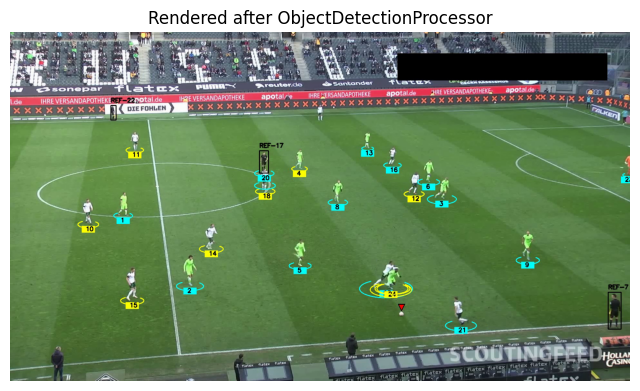

In [13]:

# read output video
output_path = "outputs/videos/demo_output.mp4"
cap = cv2.VideoCapture(output_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, 4)  # Reset to the first frame

ret, frame_det = cap.read()
cap.release()
if not ret:
    raise RuntimeError("Failed to read the output video frame.")
# Display the first frame after object detection    

plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(frame_det, cv2.COLOR_BGR2RGB))
plt.title("Rendered after ObjectDetectionProcessor")
plt.axis('off')
plt.show()


